In [ ]:
# CELDA 0 - Dependencias
!pip -q install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
# Celda 1
from google.colab import drive
drive.mount('/content/drive')

RUNS_DIR = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/runs"

import os, re, math, json, unicodedata
import pandas as pd
import numpy as np
from glob import glob
from datetime import datetime
import sacrebleu
import matplotlib.pyplot as plt

# carpeta 'eval'
EVAL_DIR = os.path.join(os.path.dirname(RUNS_DIR.rstrip("/")), "eval")
os.makedirs(EVAL_DIR, exist_ok=True)

def nfc(s: str) -> str:
    if s is None: return ""
    return unicodedata.normalize("NFC", str(s))

# --- Normalización estándar para TODAS las métricas ---
# (1) NFC + trim + colapso de espacios
# (2) Remueve SOLO punto/coma finales ('.' o ',') si están al final
_final_punct_re = re.compile(r"[.,]+$")

def std_norm_for_metrics(s: str) -> str:
    s = nfc(s).strip()
    s = re.sub(r"\s+", " ", s)
    # quitar solo punto/coma finales
    return _final_punct_re.sub("", s)

# --- Normalización adicional para Accuracy relax ---
# además de std_norm_for_metrics:
# (a) remover ¿/? SOLO si están al inicio/final
# (b) ya viene con espacios colapsados/trim
def normalize_for_acc(s: str, relax=False) -> str:
    s = std_norm_for_metrics(s)
    if relax:
        s = re.sub(r"^[¿?]\s*", "", s)
        s = re.sub(r"\s*[¿?]$", "", s)
    return s

def safe_json_list_len(x):
    try:
        if pd.isna(x): return 0
        v = json.loads(x) if isinstance(x, str) else x
        return len(v) if isinstance(v, (list, tuple)) else 0
    except Exception:
        return 0

assert os.path.exists(RUNS_DIR), f"RUNS_DIR no existe: {RUNS_DIR}"

Mounted at /content/drive


In [ ]:
# Celda 2 - Carga robusta de runs + normalización + K efectivo (K_eff)
runs_all_paths = sorted(glob(os.path.join(RUNS_DIR, "runs_all_*.csv")))
dfs = []
if runs_all_paths:
    print(f"[LOAD] runs_all_* encontrados: {len(runs_all_paths)}")
    for p in runs_all_paths:
        print("  -", os.path.basename(p))
        dfs.append(pd.read_csv(p))
else:
    print("[LOAD] No hay runs_all_*.csv; buscando run_*.csv recursivo…")
    leaf_runs = sorted(glob(os.path.join(RUNS_DIR, "**", "run_*.csv"), recursive=True))
    if not leaf_runs:
        raise FileNotFoundError("No se encontraron runs_all_*.csv ni run_*.csv en subdirectorios.")
    print(f"[LOAD] run_*.csv encontrados: {len(leaf_runs)}")
    for p in leaf_runs:
        dfs.append(pd.read_csv(p))

df = pd.concat(dfs, ignore_index=True)

# Tipos básicos y NFC
for col in ["Source","Change","pred_quz","gold_quz","model_id","split"]:
    if col in df.columns:
        df[col] = df[col].astype(str).map(nfc)

for col in ["id","K","size","with_hints","latency_ms","prompt_chars"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# K efectivo
if "kshot_ids" in df.columns:
    df["K_eff"] = df["kshot_ids"].apply(safe_json_list_len)
else:
    df["K_eff"] = np.nan
df["K_used"] = df["K_eff"]
df.loc[df["K_used"].isna(), "K_used"] = df.loc[df["K_used"].isna(), "K"]
df["K_used"] = pd.to_numeric(df["K_used"], errors="coerce").fillna(0).astype(int)

# --- NUEVO: columnas normalizadas para métricas (std para todo, relax solo para acc_relax)
df["pred_std"] = df["pred_quz"].map(std_norm_for_metrics)
df["gold_std"] = df["gold_quz"].map(std_norm_for_metrics)
df["pred_rel"] = df["pred_quz"].map(lambda x: normalize_for_acc(x, relax=True))
df["gold_rel"] = df["gold_quz"].map(lambda x: normalize_for_acc(x, relax=True))

# Accuracy por fila (usando normalizaciones)
df["acc_strict"] = (df["pred_std"] == df["gold_std"]).astype(int)
df["acc_relax"]  = (df["pred_rel"] == df["gold_rel"]).astype(int)

# Deduplicación
dedup_cols = [c for c in ["model_id","id","with_hints","K","K_used","size","split","pred_std","gold_std"] if c in df.columns]
df = df.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

print("[OK] Filas cargadas:", len(df))
display(df.head(3))

[LOAD] runs_all_* encontrados: 3
  - runs_all_20251028_091602.csv
  - runs_all_20251028_174050.csv
  - runs_all_20251028_231848.csv
[OK] Filas cargadas: 2124


,id,Source,Change,gold_quz,pred_quz,with_hints,model_id,K,split,size,...,latency_ms,error_flag,K_eff,K_used,pred_std,gold_std,pred_rel,gold_rel,acc_strict,acc_relax
0,5279,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,{ASPECT:PRG},Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,0,openai/gpt-oss-20b,5,ALL,1,...,76818,0,5,5,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,Sayk'uyninchik qhipananpaqqa apachitapi huk ru...,0,0
1,4960,Anka huk'uchata apan,{ASPECT:PRG},Anka huk'uchata apachkan,Anka huk'uchata apachkanku,0,openai/gpt-oss-20b,5,ALL,1,...,57601,0,5,5,Anka huk'uchata apachkanku,Anka huk'uchata apachkan,Anka huk'uchata apachkanku,Anka huk'uchata apachkan,0,0
2,5321,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,{ASPECT:PRG},Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,0,openai/gpt-oss-20b,5,ALL,1,...,99584,0,5,5,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,Sayk'uyniykichik qhipananpaqqa apachitapi huk ...,0,0


In [ ]:
# Celda 3 - Tablas por modelo y por K (K ∈ {5,10,15})
# - TODAS las métricas (Acc/BLEU/ChrF) calculadas sobre std_norm_for_metrics.
# - Genera:
#     1) paper_byModelK_pretty  → tabla estilo paper (modelo × K)
#     2) paper_byModel_summary  → resumen por modelo (promedios + std + rango)
#     3) by_cfg_used            → base agregada por modelo/size/K/with_hints/split (para celdas 5 y 6)
# - Se guardan en EVAL_DIR.

ALLOWED_K = {5, 10, 15}

def compute_corpus_metrics(hyps_raw, refs_raw):
    """Métricas corpus-level sobre textos normalizados con std_norm_for_metrics."""
    hyps = [std_norm_for_metrics(h) for h in hyps_raw]
    refs = [std_norm_for_metrics(r) for r in refs_raw]

    # Accuracy strict (literal) y relax
    acc_s = np.mean([h == r for h, r in zip(hyps, refs)]) * 100.0
    hyps_r = [normalize_for_acc(h, True) for h in hyps]
    refs_r = [normalize_for_acc(r, True) for r in refs]
    acc_r  = np.mean([h == r for h, r in zip(hyps_r, refs_r)]) * 100.0

    # BLEU / ChrF con sacrebleu
    bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
    chrf = sacrebleu.corpus_chrf(hyps, [refs]).score
    return dict(acc_strict=acc_s, acc_relax=acc_r, bleu=bleu, chrf=chrf)

# 1) Filtrar solo K en {5,10,15}
df_k = df[df["K"].isin(ALLOWED_K)].copy()
if df_k.empty:
    raise ValueError("No hay filas con K en {5,10,15}. Verifica tus runs.")

# 2) Tabla tipo paper por (Modelo × K)
rows = []
for (mid, Kval), g in df_k.groupby(["model_id", "K"]):
    g = g.dropna(subset=["pred_quz", "gold_quz"])
    if g.empty:
        continue
    m = compute_corpus_metrics(g["pred_quz"].tolist(), g["gold_quz"].tolist())
    rows.append(dict(
        model_id=str(mid),
        K=int(Kval),
        n=len(g),
        **m
    ))

paper_byModelK = (
    pd.DataFrame(rows)
      .sort_values(["model_id", "K"])
      .reset_index(drop=True)
)

# 2.a) Versión pretty (como en AmericasNLP)
paper_byModelK_pretty = (
    paper_byModelK
      .rename(columns={
          "acc_strict": "Acc.",
          "bleu": "BLEU",
          "chrf": "ChrF"
      })
      [["model_id", "K", "n", "Acc.", "BLEU", "ChrF"]]
)

# Mostrar una tabla por modelo (aislada) — esto sigue igual
for mid, g in paper_byModelK_pretty.groupby("model_id"):
    print(f"== Modelo: {mid} ==")
    display(
        g.sort_values("K")
         .style.format({"Acc.": "{:.2f}", "BLEU": "{:.2f}", "ChrF": "{:.2f}"})
    )

# 3) Resumen por modelo (promedio sobre K) + std + min/max
summary_rows = []
for mid, g in paper_byModelK.groupby("model_id"):
    acc_mean  = g["acc_strict"].mean()
    acc_std   = g["acc_strict"].std(ddof=0)
    acc_min   = g["acc_strict"].min()
    acc_max   = g["acc_strict"].max()

    bleu_mean = g["bleu"].mean()
    bleu_std  = g["bleu"].std(ddof=0)

    chrf_mean = g["chrf"].mean()
    chrf_std  = g["chrf"].std(ddof=0)

    summary_rows.append(dict(
        model_id = mid,
        n_total  = g["n"].sum(),          # suma de las 3 corridas K=5,10,15
        Acc_avg  = acc_mean,
        Acc_std  = acc_std,
        Acc_min  = acc_min,
        Acc_max  = acc_max,
        BLEU_avg = bleu_mean,
        BLEU_std = bleu_std,
        ChrF_avg = chrf_mean,
        ChrF_std = chrf_std,
    ))

paper_byModel_summary = (
    pd.DataFrame(summary_rows)
      .sort_values("Acc_avg", ascending=False)
      .reset_index(drop=True)
)

print("== Resumen por modelo (promedio sobre K=5,10,15) ==")
display(
    paper_byModel_summary
      .style
      .format({
          "Acc_avg": "{:.2f}",
          "Acc_std": "{:.2f}",
          "Acc_min": "{:.2f}",
          "Acc_max": "{:.2f}",
          "BLEU_avg": "{:.2f}",
          "BLEU_std": "{:.2f}",
          "ChrF_avg": "{:.2f}",
          "ChrF_std": "{:.2f}",
      })
)

# 3.a) Ranking simple (1 = mejor en Accuracy)
paper_byModel_summary["rank_by_Acc"]  = paper_byModel_summary["Acc_avg"].rank(ascending=False, method="min").astype(int)
paper_byModel_summary["rank_by_BLEU"] = paper_byModel_summary["BLEU_avg"].rank(ascending=False, method="min").astype(int)
paper_byModel_summary["rank_by_ChrF"] = paper_byModel_summary["ChrF_avg"].rank(ascending=False, method="min").astype(int)

print("== Resumen por modelo con ranking ==")
display(
    paper_byModel_summary
      [["model_id","n_total",
        "Acc_avg","Acc_std","Acc_min","Acc_max","rank_by_Acc",
        "BLEU_avg","BLEU_std","rank_by_BLEU",
        "ChrF_avg","ChrF_std","rank_by_ChrF"]]
      .style
      .format({
          "Acc_avg": "{:.2f}", "Acc_std": "{:.2f}",
          "BLEU_avg": "{:.2f}", "BLEU_std": "{:.2f}",
          "ChrF_avg": "{:.2f}", "ChrF_std": "{:.2f}",
          "Acc_min": "{:.2f}", "Acc_max": "{:.2f}",
      })
)

# 4) Base agregada por configuración (para las gráficas siguientes)
#    Ojo: ya NO necesitamos distinguir K_used vs K aquí porque ya corregimos la selección de k-shots.
group_cols = [c for c in ["model_id", "size", "K", "with_hints", "split"] if c in df_k.columns]
rows_cfg = []
for key, g in df_k.groupby(group_cols):
    g = g.dropna(subset=["pred_quz", "gold_quz"])
    if g.empty:
        continue
    m = compute_corpus_metrics(g["pred_quz"].tolist(), g["gold_quz"].tolist())
    rows_cfg.append(dict(n=len(g), **m, **{k: v for k, v in zip(group_cols, key)}))

by_cfg_used = (
    pd.DataFrame(rows_cfg)
      .sort_values(group_cols)
      .reset_index(drop=True)
)

# === (AÑADIDO) Accuracy con/sin hints por modelo × K (colocado tras "Acc.")
# Recalculamos Acc por (model_id, K, with_hints) a nivel corpus para evitar sesgos por split/size.
acc_rows = []
for (mid, Kval, wh), gsub in df_k.groupby(["model_id", "K", "with_hints"]):
    gsub = gsub.dropna(subset=["pred_quz","gold_quz"])
    if gsub.empty:
        continue
    mwh = compute_corpus_metrics(gsub["pred_quz"].tolist(), gsub["gold_quz"].tolist())
    acc_rows.append({
        "model_id": str(mid),
        "K": int(Kval),
        "with_hints": int(wh),
        "acc_wh": mwh["acc_strict"]
    })

_acc_pivot = (
    pd.DataFrame(acc_rows)
      .pivot_table(index=["model_id","K"], columns="with_hints", values="acc_wh", aggfunc="mean")
      .rename(columns={0:"Acc_nohint", 1:"Acc_hint"})
      .reset_index()
)

paper_byModelK_pretty_withHints = (
    paper_byModelK_pretty
      .merge(_acc_pivot, on=["model_id","K"], how="left")
      [["model_id","K","n","Acc.","Acc_nohint","Acc_hint","BLEU","ChrF"]]
)

# Mostrar una tabla por modelo (aislada) — con columnas Acc_nohint / Acc_hint
for mid, g in paper_byModelK_pretty_withHints.groupby("model_id"):
    print(f"== Modelo: {mid} ==")
    display(
        g.sort_values("K")
         .style.format({"Acc.": "{:.2f}", "Acc_nohint": "{:.2f}", "Acc_hint": "{:.2f}",
                        "BLEU": "{:.2f}", "ChrF": "{:.2f}"})
    )

# 5) Guardar todo en EVAL_DIR
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
paper_path        = os.path.join(EVAL_DIR, f"paper_byModelK_{ts}.csv")
paper_hints_path  = os.path.join(EVAL_DIR, f"paper_byModelK_withHints_{ts}.csv")  # <-- nuevo
summary_path      = os.path.join(EVAL_DIR, f"paper_byModel_summary_{ts}.csv")
cfg_path          = os.path.join(EVAL_DIR, f"by_cfg_USED_Konly_{ts}.csv")

paper_byModelK_pretty.to_csv(paper_path, index=False, encoding="utf-8")
paper_byModelK_pretty_withHints.to_csv(paper_hints_path, index=False, encoding="utf-8")  # <-- nuevo
paper_byModel_summary.to_csv(summary_path, index=False, encoding="utf-8")
by_cfg_used.to_csv(cfg_path, index=False, encoding="utf-8")

print("[SAVED → EVAL_DIR]")
print("-", paper_path)
print("-", paper_hints_path)  # <-- nuevo
print("-", summary_path)
print("-", cfg_path)

# === [ANEXO ESTADÍSTICO — Comparaciones inferenciales por modelo] ===
from scipy.stats import wilcoxon, kruskal, mannwhitneyu

# 1) Normalización por-fila para métricas oracionales
if "_pred_std" not in df.columns or "_gold_std" not in df.columns:
    df["_pred_std"] = df["pred_quz"].map(std_norm_for_metrics)
    df["_gold_std"] = df["gold_quz"].map(std_norm_for_metrics)

# Accuracy binario por fila (estricto tras std_norm)
if "_acc_row_bin" not in df.columns:
    df["_acc_row_bin"] = (df["_pred_std"] == df["_gold_std"]).astype(int)

# chrF oracional por fila (sobre std_norm)
if "_chrf_row" not in df.columns:
    try:
        # sacrebleu >= 2.x
        from sacrebleu.metrics import CHRF
        _chrf_metric = CHRF(word_order=0)  # chrF++
        df["_chrf_row"] = df.apply(lambda r: _chrf_metric.sentence_score(r["_pred_std"], [r["_gold_std"]]).score, axis=1)
    except Exception:
        # Fallback usando sentence_chrf si está disponible
        try:
            from sacrebleu import sentence_chrf
            df["_chrf_row"] = df.apply(lambda r: sentence_chrf(r["_pred_std"], [r["_gold_std"]]).score, axis=1)
        except Exception:
            # Último recurso: aproximación simple (no ideal)
            def _approx_chrf(h, r, n_max=6, beta=2.0):
                h = str(h); r = str(r)
                if not h and not r: return 100.0
                if not h or not r:  return 0.0
                def ngrams(s, n):
                    return [tuple(s[i:i+n]) for i in range(len(s)-n+1)]
                P = R = 0.0
                for n in range(1, n_max+1):
                    hg = ngrams(h, n); rg = ngrams(r, n)
                    if not hg or not rg:
                        continue
                    from collections import Counter
                    ch = Counter(hg); cr = Counter(rg)
                    overlap = sum((ch & cr).values())
                    p = overlap / max(1, sum(ch.values()))
                    r_ = overlap / max(1, sum(cr.values()))
                    P += p; R += r_
                P /= n_max; R /= n_max
                if P==0 and R==0: return 0.0
                beta2 = beta*beta
                return 100.0 * (1+beta2)*P*R/(beta2*P+R)
            df["_chrf_row"] = df.apply(lambda r: _approx_chrf(r["_pred_std"], r["_gold_std"]), axis=1)

# 2) Helper de formato para p-values (2 decimales y 10^-6)
def _fmt_p_2dec_e6(p):
    try:
        p = float(p)
    except Exception:
        return str(p)
    if np.isnan(p):
        return "NaN"
    if p < 1e-6:
        return "< 1.00×10⁻⁶"
    s = f"{p:.2e}"       # ej. 1.23e-05
    base, exp = s.split('e')
    exp = int(exp)
    _sup = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")
    exp_sup = str(exp).translate(_sup)
    return f"{base}×10{exp_sup}"

def _slug(s):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(s))

# 3) WILCOXON (pareado hints vs no-hints) — por modelo
wilcoxon_rows = []
key_pair = [c for c in ["model_id","split","size","K","id"] if c in df.columns]

# Métricas fila a fila que sí son apropiadas para Wilcoxon (ordinal/continua pareada)
WILCOXON_METRICS = {
    "acc_bin": "_acc_row_bin",   # exact match 0/1
    "chrf":    "_chrf_row"       # chrF por oración
}

for mid, gmid in df.groupby("model_id"):
    # Preparamos pares: merge no-hints vs hints por llave de emparejamiento
    left  = gmid[gmid["with_hints"]==0][key_pair + list(WILCOXON_METRICS.values())].copy()
    right = gmid[gmid["with_hints"]==1][key_pair + list(WILCOXON_METRICS.values())].copy()
    if left.empty or right.empty:
        continue
    merged = pd.merge(left, right, on=key_pair, suffixes=("_no","_hi"))
    if merged.empty:
        continue

    for mname, mcol in WILCOXON_METRICS.items():
        a = merged[f"{mcol}_no"].astype(float).values
        b = merged[f"{mcol}_hi"].astype(float).values
        # Requiere valores distintos para evitar ValueError (todas diferencias=0)
        try:
            stat, p = wilcoxon(a, b, zero_method="wilcox", alternative="two-sided", method="auto")
            n_eff = len(a)
        except ValueError:
            stat, p, n_eff = np.nan, np.nan, len(a)

        wilcoxon_rows.append(dict(
            model_id=mid, metric=("Accuracy (binaria)" if mname=="acc_bin" else "chrF (oracional)"),
            n=n_eff, stat=stat, p_value=p
        ))

wilcoxon_table = pd.DataFrame(wilcoxon_rows)

# 4) Efecto de K — KRUSKAL (global) y MANN–WHITNEY por pares de K — por modelo
ALLOWED_K = {5, 10, 15}
pairs_K = [(5,10), (10,15), (5,15)]
stats_rows = []

for mid, gmid in df[df["K"].isin(ALLOWED_K)].groupby("model_id"):
    for mname, mcol in WILCOXON_METRICS.items():
        # Kruskal sobre 3 grupos (K=5,10,15) — usa todas las filas disponibles por K
        samples = []
        labels  = []
        for k in sorted(ALLOWED_K):
            vec = gmid[gmid["K"]==k][mcol].astype(float).values
            if len(vec) > 0:
                samples.append(vec)
                labels.append(k)
        if len(samples) >= 2:
            try:
                k_stat, k_p = kruskal(*samples)
            except Exception:
                k_stat, k_p = np.nan, np.nan
            stats_rows.append(dict(
                model_id=mid, metric=("Accuracy (binaria)" if mname=="acc_bin" else "chrF (oracional)"),
                test="Kruskal (5,10,15)", K_pair="all", stat=k_stat, p_value=k_p
            ))

        # Mann–Whitney U por pares (independiente por conveniencia)
        for (k1, k2) in pairs_K:
            v1 = gmid[gmid["K"]==k1][mcol].astype(float).values
            v2 = gmid[gmid["K"]==k2][mcol].astype(float).values
            if len(v1) > 0 and len(v2) > 0:
                try:
                    u_stat, u_p = mannwhitneyu(v1, v2, alternative="two-sided", method="asymptotic")
                except Exception:
                    u_stat, u_p = np.nan, np.nan
                stats_rows.append(dict(
                    model_id=mid, metric=("Accuracy (binaria)" if mname=="acc_bin" else "chrF (oracional)"),
                    test="Mann–Whitney", K_pair=f"{k1} vs {k2}", stat=u_stat, p_value=u_p
                ))

stats_byK_table = pd.DataFrame(stats_rows)

# 5) Impresión bonita y guardado — Tablas separadas por modelo
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

# Wilcoxon por modelo
if not wilcoxon_table.empty:
    print("== Wilcoxon (hints vs no-hints) — Tablas separadas por modelo ==")
    for mid, g in wilcoxon_table.groupby("model_id"):
        print(f"\n-- Modelo: {mid} --")
        disp = g[["metric","n","stat","p_value"]].reset_index(drop=True)
        display(disp.style.format({"stat":"{:.3f}","p_value": _fmt_p_2dec_e6}))
        out_path = os.path.join(EVAL_DIR, f"stats_wilcoxon_{_slug(mid)}_{ts}.csv")
        disp.to_csv(out_path, index=False, encoding="utf-8")
        print("Guardado:", out_path)
else:
    print("[INFO] Wilcoxon: no hay datos suficientes para formar pares hints/no-hints.")

# Kruskal/Mann–Whitney por modelo
if not stats_byK_table.empty:
    print("\n== Efecto de K (5/10/15): Kruskal & Mann–Whitney — Tablas separadas por modelo ==")
    for mid, g in stats_byK_table.groupby("model_id"):
        print(f"\n-- Modelo: {mid} --")
        disp = g[["metric","test","K_pair","stat","p_value"]].reset_index(drop=True)
        display(disp.style.format({"stat":"{:.3f}","p_value": _fmt_p_2dec_e6}))
        out_path = os.path.join(EVAL_DIR, f"stats_byK_{_slug(mid)}_{ts}.csv")
        disp.to_csv(out_path, index=False, encoding="utf-8")
        print("Guardado:", out_path)
else:
    print("[INFO] Efecto de K: no hay filas con K en {5,10,15}.")

== Modelo: mistral-small-3.2-24b-instruct-2506 ==


,model_id,K,n,Acc.,BLEU,ChrF
0,mistral-small-3.2-24b-instruct-2506,5,236,52.54,67.21,90.69
1,mistral-small-3.2-24b-instruct-2506,10,236,55.08,69.94,90.28
2,mistral-small-3.2-24b-instruct-2506,15,236,53.39,69.00,89.83


== Modelo: openai/gpt-oss-20b ==


,model_id,K,n,Acc.,BLEU,ChrF
3,openai/gpt-oss-20b,5,236,44.07,63.94,91.21
4,openai/gpt-oss-20b,10,236,48.73,66.58,92.63
5,openai/gpt-oss-20b,15,236,53.81,70.54,93.95


== Modelo: qwen-qwen2.5-14b-instruct-1m ==


...

Guardado: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/stats_byK_mistral-small-3.2-24b-instruct-2506_20251124_000838.csv

-- Modelo: openai/gpt-oss-20b --


,metric,test,K_pair,stat,p_value
0,Accuracy (binaria),"Kruskal (5,10,15)",all,4.482,1.06×10⁻¹
1,Accuracy (binaria),Mann–Whitney,5 vs 10,26550.000,3.11×10⁻¹
2,Accuracy (binaria),Mann–Whitney,10 vs 15,26432.000,2.70×10⁻¹
3,Accuracy (binaria),Mann–Whitney,5 vs 15,25134.000,3.44×10⁻²
4,chrF (oracional),"Kruskal (5,10,15)",all,4.519,1.04×10⁻¹
5,chrF (oracional),Mann–Whitney,5 vs 10,26587.000,3.69×10⁻¹
6,chrF (oracional),Mann–Whitney,10 vs 15,26186.500,2.28×10⁻¹
7,chrF (oracional),Mann–Whitney,5 vs 15,24889.000,3.34×10⁻²


Guardado: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/stats_byK_openai_gpt-oss-20b_20251124_000838.csv

-- Modelo: qwen-qwen2.5-14b-instruct-1m --


,metric,test,K_pair,stat,p_value
0,Accuracy (binaria),"Kruskal (5,10,15)",all,9.724,7.74×10⁻³
1,Accuracy (binaria),Mann–Whitney,5 vs 10,25134.000,3.45×10⁻²
2,Accuracy (binaria),Mann–Whitney,10 vs 15,26668.000,3.54×10⁻¹
3,Accuracy (binaria),Mann–Whitney,5 vs 15,23954.000,2.39×10⁻³
4,chrF (oracional),"Kruskal (5,10,15)",all,10.932,4.23×10⁻³
5,chrF (oracional),Mann–Whitney,5 vs 10,24883.000,3.26×10⁻²
6,chrF (oracional),Mann–Whitney,10 vs 15,26384.000,2.74×10⁻¹
7,chrF (oracional),Mann–Whitney,5 vs 15,23405.500,1.23×10⁻³


Guardado: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/stats_byK_qwen-qwen2.5-14b-instruct-1m_20251124_000838.csv


In [ ]:
# Celda 4 - Comparativa hints vs no-hints (K) — Solo cálculo y guardado, **sin imprimir tablas**
# (Se mantienen los CSV por si luego quieres auditar; no hay display())

# ---- K (pedido) ----
key_cols_req = [c for c in ["model_id","size","K","split","id"] if c in df.columns]
need_cols_req = key_cols_req + ["with_hints","pred_quz","gold_quz"]
sub_req = df[df["K"].isin({5,10,15})][need_cols_req].dropna(subset=["with_hints"]).copy()

# Accuracy binario (estricto con std_norm) para comparación por fila
def _acc_bin(h, r):
    return int(std_norm_for_metrics(h) == std_norm_for_metrics(r))

sub_req["acc_bin"] = [_acc_bin(h, r) for h, r in zip(sub_req["pred_quz"], sub_req["gold_quz"])]

left_r  = sub_req[sub_req["with_hints"]==0].rename(columns={"pred_quz":"pred_nohint","acc_bin":"acc_nohint"})
right_r = sub_req[sub_req["with_hints"]==1].rename(columns={"pred_quz":"pred_hint","acc_bin":"acc_hint"})

cmp_req = pd.merge(
    left_r[key_cols_req+["pred_nohint","acc_nohint"]],
    right_r[key_cols_req+["pred_hint","acc_hint"]],
    on=key_cols_req, how="outer"
)

def winner(a0, a1):
    if pd.isna(a0) and pd.notna(a1): return "hint"
    if pd.isna(a1) and pd.notna(a0): return "nohint"
    if pd.isna(a0) and pd.isna(a1):  return "tie"
    if a0 > a1: return "nohint"
    if a1 > a0: return "hint"
    return "tie"

cmp_req["winner"] = [winner(a0, a1) for a0, a1 in zip(cmp_req["acc_nohint"], cmp_req["acc_hint"])]

sum_cols_req = [c for c in ["model_id","size","K","split"] if c in cmp_req.columns]
wins_req = (cmp_req
            .groupby(sum_cols_req, dropna=False)["winner"]
            .value_counts()
            .unstack(fill_value=0)
            .reset_index())
for lab in ["hint","nohint","tie"]:
    if lab not in wins_req.columns: wins_req[lab] = 0
wins_req["n"] = wins_req[["hint","nohint","tie"]].sum(1)
for lab in ["hint","nohint","tie"]:
    wins_req[f"pct_{lab}"] = 100.0 * wins_req[lab] / wins_req["n"].replace(0, np.nan)

# Guardados en EVAL_DIR (sin display)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
cmp_req_path = os.path.join(EVAL_DIR, f"eval_cmp_rows_REQ_{ts}.csv")
wins_req_path = os.path.join(EVAL_DIR, f"eval_wins_REQ_{ts}.csv")
cmp_req.to_csv(cmp_req_path, index=False, encoding="utf-8")
wins_req.to_csv(wins_req_path, index=False, encoding="utf-8")
print("[SAVED → EVAL_DIR]")
print("-", cmp_req_path)
print("-", wins_req_path)

[SAVED → EVAL_DIR]
- /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/eval_cmp_rows_REQ_20251105_203547.csv
- /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/eval_wins_REQ_20251105_203547.csv


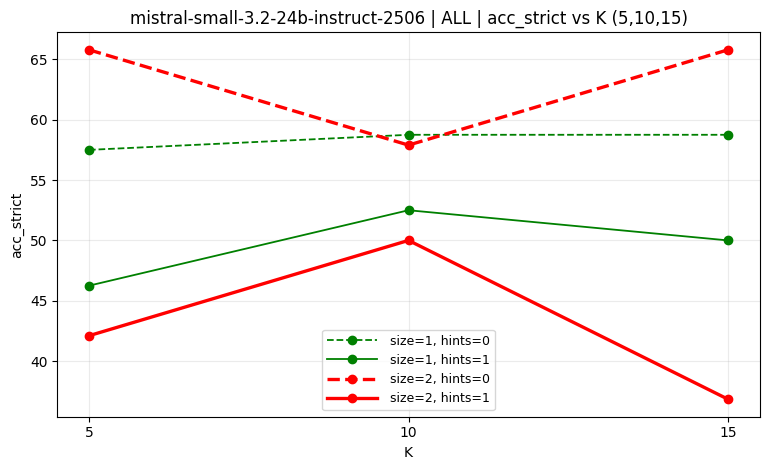

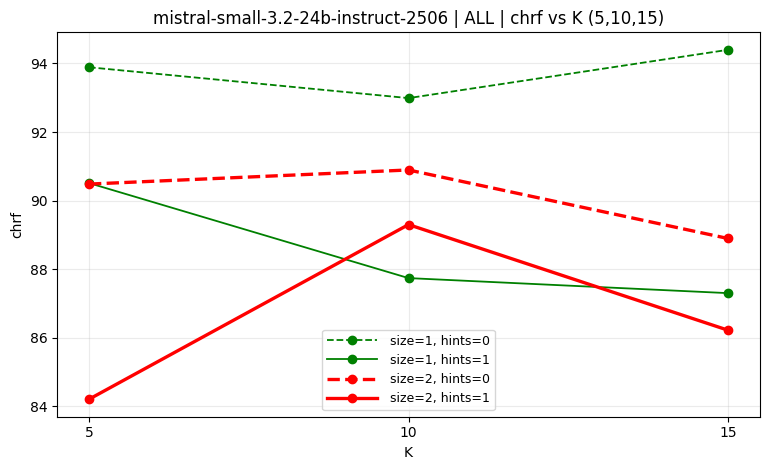

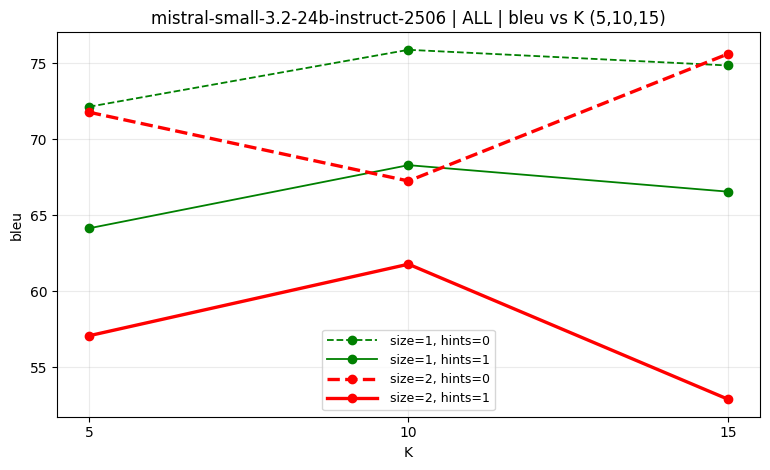

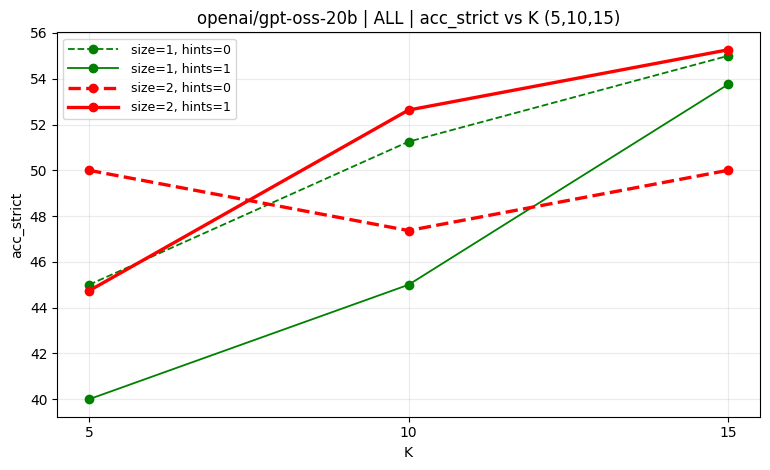

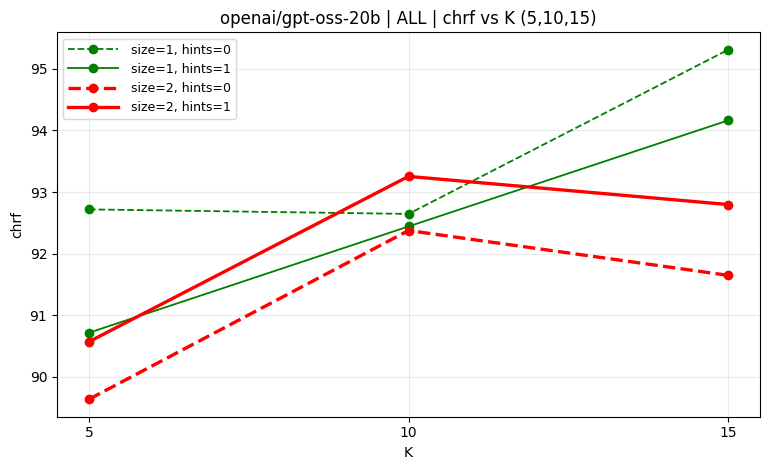

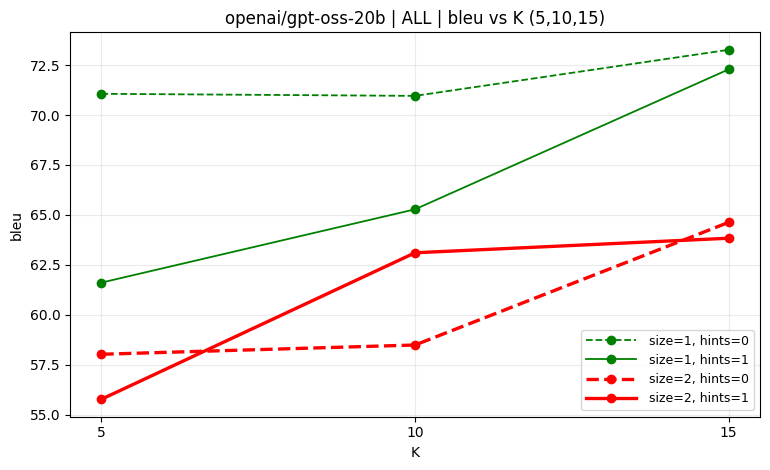

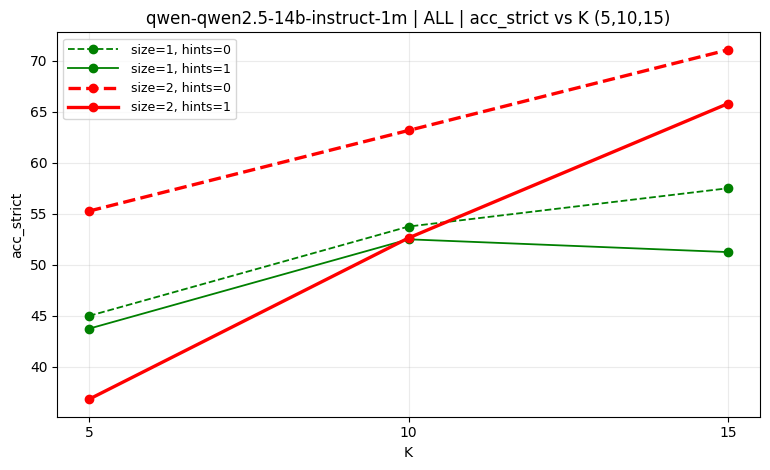

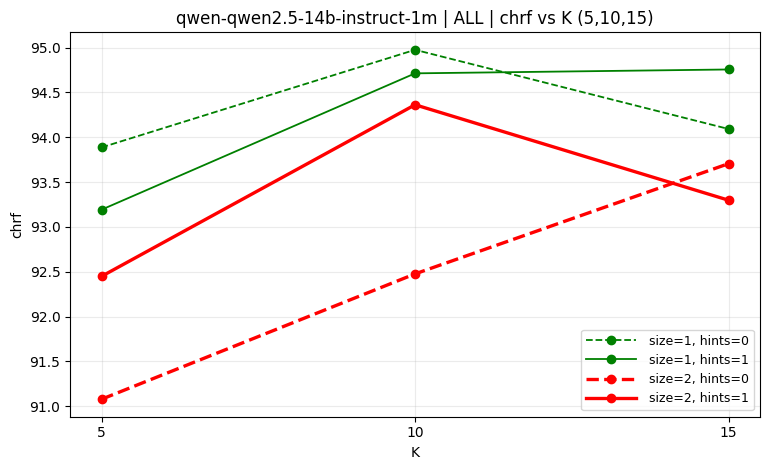

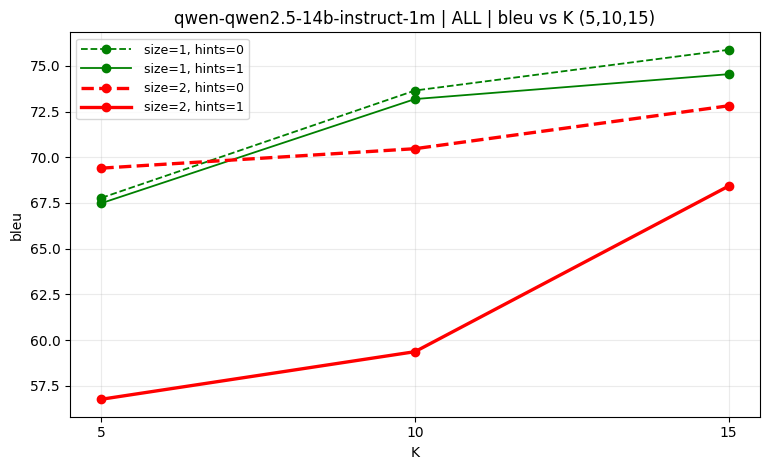

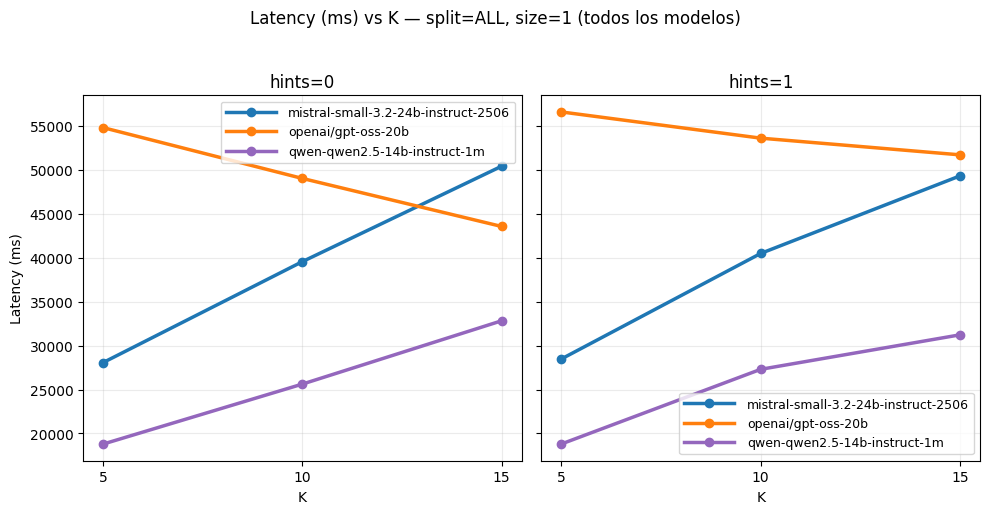

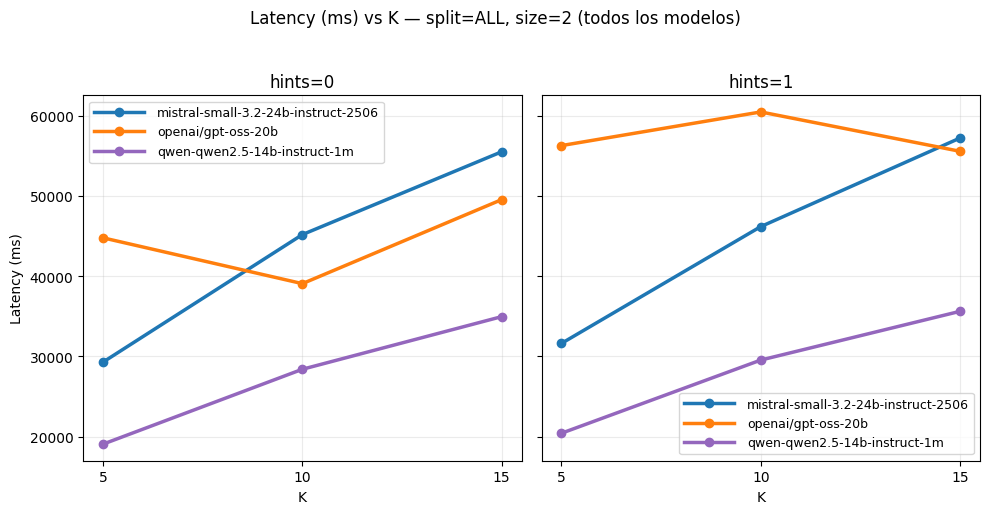

In [ ]:
# CELDA 5 — Curvas por K (métricas) + Eficiencia (accuracy vs tiempo, modelos combinados)
# Filtro: usar SOLO K en {5, 10, 15}. Estilos:
# - Métricas: color por size (1=verde, 2=rojo), estilo por hints (0=--, 1=-).
# - Latencia combinada (todos los modelos): color por modelo.

from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import numpy as np

ALLOWED_K = {5, 10, 15}
metrics_cols = ["acc_strict", "chrf", "bleu"]

# === Helpers de estilo ===
COLOR_SIZE = {1: "green", 2: "red"}

def _linewidth_for_size(sz):
    try:
        sz = int(sz)
    except Exception:
        return 2.0
    return {1: 1.3, 2: 2.4}.get(sz, 2.0)

def _linestyle_for_hints(wh):
    # 0 => no-hints => discontinua, 1 => hints => sólida
    return "-" if int(wh) == 1 else "--"

def _series_xy(g, metric, xcol="K"):
    gg = g.sort_values([xcol])
    x = gg[xcol].values
    y = gg[metric].values
    return x, y

# ========= 5.1 Curvas de métricas vs K (K en {5,10,15}), facet por modelo y split =========
# Usamos el agregado by_cfg_used que viene de la Celda 3 (ya basado en K).
by_cfg_used_f = by_cfg_used[by_cfg_used["K"].isin(ALLOWED_K)].copy()
if by_cfg_used_f.empty:
    raise ValueError("No hay datos en by_cfg_used para K ∈ {5,10,15}. Revisa la Celda 3.")

for model in sorted(by_cfg_used_f["model_id"].dropna().unique()):
    gmodel = by_cfg_used_f[by_cfg_used_f["model_id"] == model]
    for split in sorted(gmodel["split"].dropna().unique()):
        gsplit = gmodel[gmodel["split"] == split]
        if gsplit.empty:
            continue
        for mcol in metrics_cols:
            plt.figure(figsize=(7.8, 4.8))
            plt.title(f"{model} | {split} | {mcol} vs K (5,10,15)")
            for (sz, wh), g in gsplit.groupby(["size", "with_hints"]):
                if g.empty:
                    continue
                x, y = _series_xy(g, mcol, xcol="K")
                if len(x) == 0:
                    continue
                lw = _linewidth_for_size(sz)
                ls = _linestyle_for_hints(wh)
                c  = COLOR_SIZE.get(int(sz), "gray")
                label = f"size={int(sz)}, hints={int(wh)}"
                plt.plot(x, y, marker="o", linestyle=ls, linewidth=lw, color=c, label=label)
            ax = plt.gca()
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            xticks = [k for k in sorted(gsplit["K"].dropna().unique()) if k in ALLOWED_K]
            plt.xticks(xticks, [str(int(k)) for k in xticks])
            plt.xlabel("K")
            plt.ylabel(mcol)
            plt.grid(alpha=0.25)
            # Para que la leyenda muestre bien estilo y grosor
            plt.legend(
                title="",
                fontsize=9,
                handlelength=4.0,
                handleheight=0.8,
                handletextpad=1.0,
                borderpad=0.4,
            )
            plt.tight_layout()
            plt.show()

# ========= 5.2 Eficiencia — COMBINADA: Latencia (ms) vs K con todos los modelos (5/10/15) =========
# Creamos accuracy binario por fila con la normalización estándar (sin depender de columnas previas)
def _acc_bin_std(h, r):
    return int(std_norm_for_metrics(h) == std_norm_for_metrics(r))

df_eff = df[df["K"].isin(ALLOWED_K)].copy()
df_eff = df_eff.dropna(subset=["pred_quz", "gold_quz"])
df_eff["acc_row_bin"] = [_acc_bin_std(h, r) for h, r in zip(df_eff["pred_quz"], df_eff["gold_quz"])]

# Agregado: por modelo / split / size / K / with_hints
agg_eff_all = (df_eff.groupby(["model_id", "split", "size", "K", "with_hints"], as_index=False)
               .agg(acc_row_mean=("acc_row_bin", "mean"),
                    latency_ms_mean=("latency_ms", "mean"),
                    n=("id", "count")))
# Accuracy en %
agg_eff_all["acc_row_mean"] = agg_eff_all["acc_row_mean"] * 100.0

# Paleta por modelo para la figura combinada de latencia
all_models = sorted(agg_eff_all["model_id"].dropna().unique())
model_palette = [
    "tab:blue", "tab:orange", "tab:purple", "tab:brown",
    "tab:cyan", "tab:pink", "tab:olive", "tab:gray",
    "tab:green", "tab:red"
]
model_color = {m: model_palette[i % len(model_palette)] for i, m in enumerate(all_models)}

all_splits = sorted(agg_eff_all["split"].dropna().unique())
all_sizes  = sorted(agg_eff_all["size"].dropna().unique())
all_whs    = sorted(agg_eff_all["with_hints"].dropna().unique())

# ---- MODIFICACIÓN: agrupar en SOLO 2 figuras por split (size=1 y size=2), con hints=0 y 1 en horizontal ----
for split in all_splits:
    for sz in all_sizes:
        # Creamos una sola figura con 2 subplots horizontales: izquierda hints=0, derecha hints=1
        fig, axs = plt.subplots(1, 2, figsize=(10.0, 5.2), sharey=True)
        fig.suptitle(f"Latency (ms) vs K — split={split}, size={int(sz)} (todos los modelos)", fontsize=12)

        # Asegurar orden de hints [0,1] si existen
        wh_order = [w for w in [0, 1] if w in set(all_whs)] or list(all_whs)

        for idx, wh in enumerate(wh_order):
            ax = axs[idx]
            sub = agg_eff_all[(agg_eff_all["split"] == split) &
                              (agg_eff_all["size"] == sz) &
                              (agg_eff_all["with_hints"] == wh)].copy()
            ax.set_title(f"hints={int(wh)}")
            if sub.empty:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
                ax.grid(True, alpha=0.25)
                continue

            xticks = sorted(sub["K"].dropna().unique())
            for model in all_models:
                gm = sub[sub["model_id"] == model].sort_values(["K"])
                if gm.empty:
                    continue
                x = gm["K"].values
                y = gm["latency_ms_mean"].values
                ax.plot(x, y, marker="o", linewidth=2.5, color=model_color[model], label=model)

            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.set_xticks(xticks)
            ax.set_xticklabels([str(int(k)) for k in xticks])
            ax.set_xlabel("K")
            ax.grid(True, alpha=0.25)

        # Etiqueta Y compartida
        axs[0].set_ylabel("Latency (ms)")

        # Leyendas: para mantener cambios mínimos, dejamos una leyenda por subplot
        for ax in axs:
            ax.legend(
                title="",
                fontsize=9,
                handlelength=4.0,
                handleheight=0.8,
                handletextpad=1.0,
                borderpad=0.4,
            )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

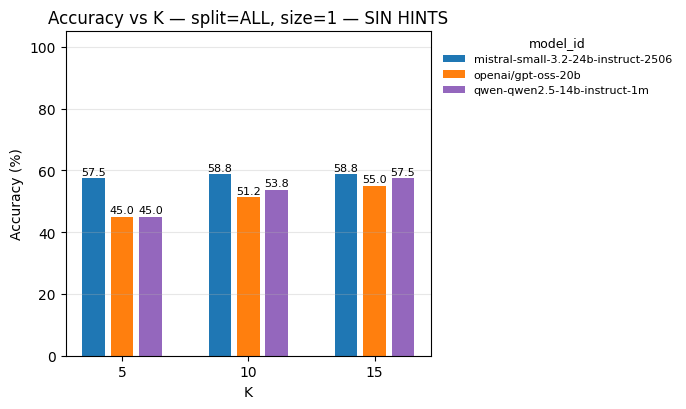

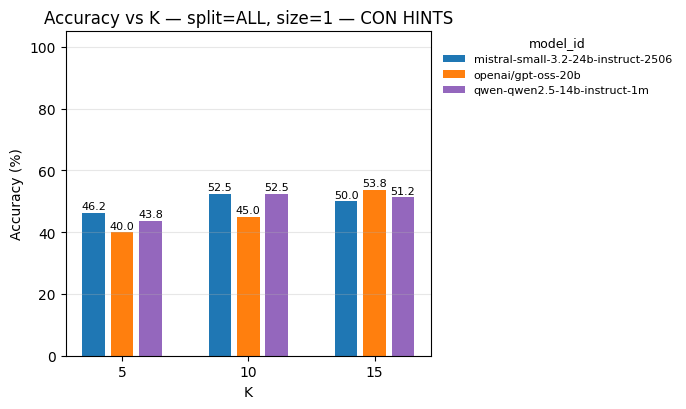

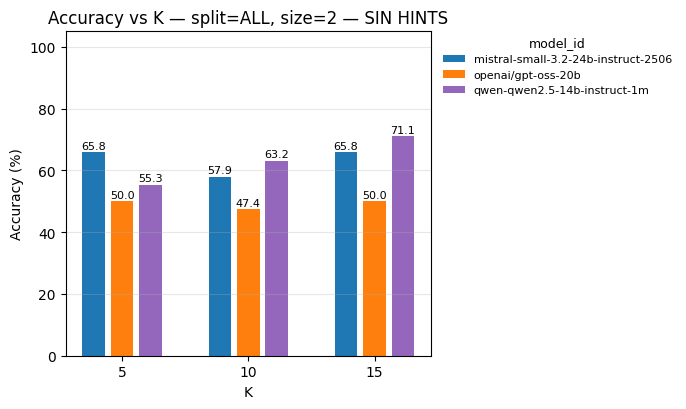

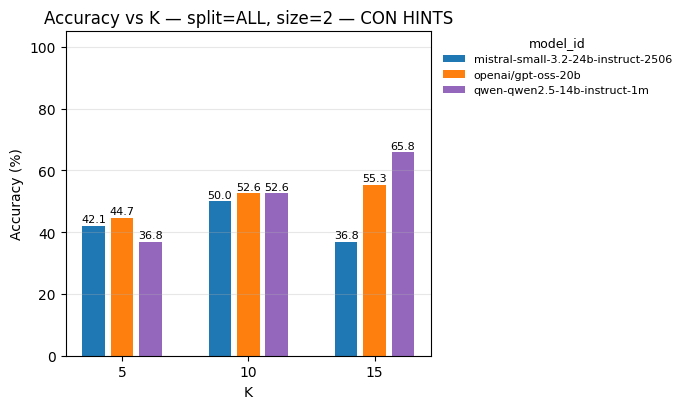

,model_id,K,primary_change,n,Acc.,acc_relax,BLEU,ChrF
0,mistral-small-3.2-24b-instruct-2506,5,ASPECT,30,50.00,50.000000,70.40,90.26
1,mistral-small-3.2-24b-instruct-2506,10,ASPECT,30,53.33,53.333333,73.12,88.01
2,mistral-small-3.2-24b-instruct-2506,15,ASPECT,30,53.33,53.333333,65.06,86.70
3,openai/gpt-oss-20b,5,ASPECT,30,36.67,36.666667,60.47,90.10
4,openai/gpt-oss-20b,10,ASPECT,30,46.67,46.666667,69.06,94.75
5,openai/gpt-oss-20b,15,ASPECT,30,56.67,56.666667,75.16,95.13
6,qwen-qwen2.5-14b-instruct-1m,5,ASPECT,30,50.00,50.000000,82.41,94.04
7,qwen-qwen2.5-14b-instruct-1m,10,ASPECT,30,63.33,63.333333,85.92,94.30
8,qwen-qwen2.5-14b-instruct-1m,15,ASPECT,30,63.33,63.333333,85.35,97.37
9,mistral-small-3.2-24b-instruct-2506,5,NUMBER,34,20.59,20.588235,33.87,79.20


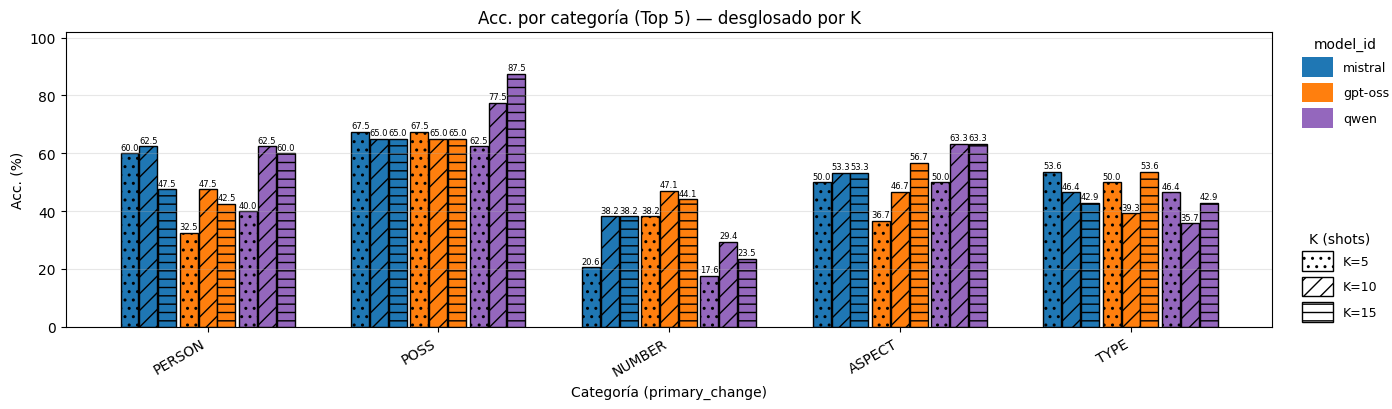

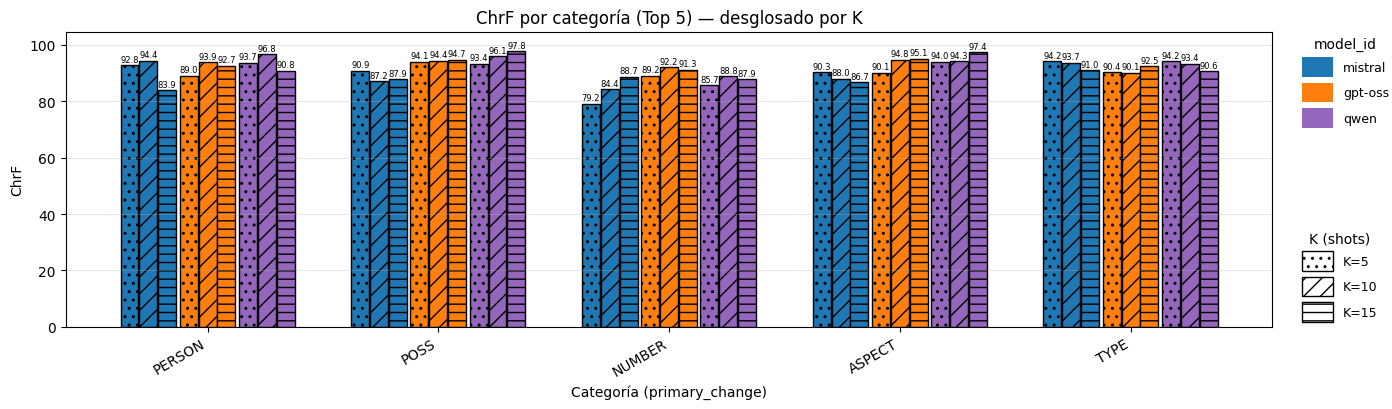

In [ ]:
# CELDA 6 — Barras separadas (sin apilar) para no-hints / hints + análisis por categoría
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


ALLOWED_K = {5, 10, 15}

def _acc_bin_std(h, r):
    return int(std_norm_for_metrics(h) == std_norm_for_metrics(r))

# --- 6.1 Accuracy por modelo, por K, con y sin hints (barras agrupadas) ---
df_sep = df[df["K"].isin(ALLOWED_K)].dropna(subset=["pred_quz","gold_quz"]).copy()
df_sep["acc_row_bin"] = [_acc_bin_std(h, r) for h, r in zip(df_sep["pred_quz"], df_sep["gold_quz"])]

agg_sep = (
    df_sep.groupby(["model_id","split","size","K","with_hints"], as_index=False)
          .agg(acc_pct=("acc_row_bin", lambda x: 100.0 * float(np.mean(x))),
               n=("id","count"))
)

all_models = sorted(agg_sep["model_id"].dropna().unique())
model_palette = [
    "tab:blue","tab:orange","tab:purple","tab:brown",
    "tab:cyan","tab:pink","tab:olive","tab:gray",
    "tab:green","tab:red"
]
model_color = {m: model_palette[i % len(model_palette)] for i, m in enumerate(all_models)}

def _plot_accuracy_bars(split, size, wh_flag, title_suffix):
    sub = agg_sep[(agg_sep["split"]==split)&(agg_sep["size"]==size)&(agg_sep["with_hints"]==wh_flag)].copy()
    if sub.empty:
        return

    Ks = [k for k in [5,10,15] if k in set(sub["K"].tolist())]
    if not Ks:
        return

    x_base = np.arange(len(Ks), dtype=float)
    width  = min(0.8 / max(1, len(all_models)), 0.18)
    offsets = (np.arange(len(all_models)) - (len(all_models)-1)/2) * width * 1.25

    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.set_title(f"Accuracy vs K — split={split}, size={int(size)} — {title_suffix}", fontsize=12)

    for i, model in enumerate(all_models):
        gm = sub[sub["model_id"]==model]
        vals = [gm[gm["K"]==k]["acc_pct"].mean() if (gm["K"]==k).any() else np.nan for k in Ks]
        xpos = x_base + offsets[i]
        ax.bar(xpos, vals, width=width, label=model, color=model_color[model])
        for xv, v in zip(xpos, vals):
            if not np.isnan(v):
                ax.text(xv, v + 0.5, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xticks(x_base)
    ax.set_xticklabels([str(k) for k in Ks])
    ax.set_xlabel("K", fontsize=10)
    ax.set_ylabel("Accuracy (%)", fontsize=10)
    ax.set_ylim(0, 105)   # <-- un poquito más arriba de 100 para que el texto no se pegue
    ax.grid(axis="y", alpha=0.3)

    # Leyenda fuera, a la derecha
    ax.legend(title="model_id",
              ncol=1,
              fontsize=8,
              title_fontsize=9,
              frameon=False,
              bbox_to_anchor=(1.02, 1),
              loc="upper left",
              borderaxespad=0.0)

    fig.tight_layout()
    plt.show()

for split in sorted(agg_sep["split"].dropna().unique()):
    for sz in sorted(agg_sep["size"].dropna().unique()):
        _plot_accuracy_bars(split, sz, wh_flag=0, title_suffix="SIN HINTS")
        _plot_accuracy_bars(split, sz, wh_flag=1, title_suffix="CON HINTS")

# --- 6.2 Análisis por categoría (primary_change) — desglosado por K (5, 10, 15) ---

# Mapeo corto de modelos (única modificación importante)
model_shortname = {
    "mistral-small-3.2-24b-instruct-2506": "mistral",
    "openai/gpt-oss-20b": "gpt-oss",
    "qwen-qwen2.5-14b-instruct-1m": "qwen"
}

if "primary_change" in df.columns and df["primary_change"].notna().any():
    # Tomamos solo las K permitidas y rows con pred/gold válidos
    df_k = df[df["K"].isin(ALLOWED_K)].dropna(subset=["pred_quz", "gold_quz"]).copy()

    # Top 5 categorías más frecuentes dentro de ese subconjunto
    top_cats = df_k["primary_change"].value_counts().head(5).index.tolist()
    df_cat = df_k[df_k["primary_change"].isin(top_cats)].copy()

    # Agrupamos por modelo, K y categoría
    rows_catK = []
    for (model, K, cat), g in df_cat.groupby(["model_id", "K", "primary_change"]):
        m = compute_corpus_metrics(g["pred_quz"].tolist(), g["gold_quz"].tolist())
        rows_catK.append(dict(
            model_id=model,
            K=K,
            primary_change=cat,
            n=len(g),
            **m
        ))

    paper_byCatK = pd.DataFrame(rows_catK).sort_values(
        ["primary_change","model_id","K"]
    ).reset_index(drop=True)

    # Renombramos métrica de accuracy y ChrF como antes
    paper_byCatK = paper_byCatK.rename(columns={
        "acc_strict": "Acc.",
        "bleu": "BLEU",
        "chrf": "ChrF"
    })

    # Tabla resumida (puedes dejarla así o filtrar)
    display(
        paper_byCatK.style.format({
            "Acc.": "{:.2f}",
            "BLEU": "{:.2f}",
            "ChrF": "{:.2f}"
        })
    )

    # ---- Plots: para cada métrica, barras por categoría, color=modelo, textura=K ----
    hatch_map = {
        5: "..",
        10: "//",
        15: "--"
    }

    top_cats = list(top_cats)  # asegurar orden estable
    Ks_present = sorted(paper_byCatK["K"].unique())

    # Spacing between category groups - reduced from 1.0 to 0.4
    category_spacing = 0.4
    x = np.arange(len(top_cats), dtype=float) * (1 + category_spacing)

    for metric in ["Acc.", "ChrF"]:
        # Calculate proper figure width based on categories and spacing
        fig_width = max(12.0, len(top_cats) * (1 + category_spacing) * 2)
        fig, ax = plt.subplots(figsize=(fig_width, 4.2))
        ax.set_title(f"{metric} por categoría (Top 5) — desglosado por K", fontsize=12)

        num_models = len(all_models)
        num_K = len(Ks_present)

        # Bar width - keep it reasonable
        total_bars_per_category = num_models * num_K
        width = 0.98 / total_bars_per_category

        for i, model in enumerate(all_models):
            gm = paper_byCatK[paper_byCatK["model_id"] == model]
            if gm.empty:
                continue

            # Offset base por modelo (grupo de Ks)
            model_offset = (i - (num_models - 1) / 2.0) * (num_K * width * 1.1)

            for j, K in enumerate(Ks_present):
                gmk = gm[gm["K"] == K]
                if gmk.empty:
                    continue

                # Valores por categoría para este modelo y este K
                vals = [
                    gmk[gmk["primary_change"] == c][metric].mean()
                    if (gmk["primary_change"] == c).any() else np.nan
                    for c in top_cats
                ]

                # Offset interno para distinguir los Ks dentro del grupo del modelo
                k_offset = (j - (num_K - 1) / 2.0) * (width * 1.05)
                xpos = x + model_offset + k_offset

                ax.bar(
                    xpos,
                    vals,
                    width=width,
                    color=model_color.get(model, "tab:gray"),
                    hatch=hatch_map.get(K, ""),
                    edgecolor="black"
                )

                # Etiquetas encima de cada barra
                for xv, v in zip(xpos, vals):
                    if not np.isnan(v):
                        ax.text(
                            xv,
                            v + 0.5,
                            f"{v:.1f}",
                            ha="center",
                            va="bottom",
                            fontsize=6
                        )

        ax.set_xticks(x)
        ax.set_xticklabels(top_cats, rotation=30, ha="right")
        ax.set_xlabel("Categoría (primary_change)", fontsize=10)
        ax.set_ylabel(f"{metric} (%)" if metric == "Acc." else metric, fontsize=10)

        if metric == "Acc.":
            ymax = 100
        else:
            ymax = max(100, np.nanmax(paper_byCatK[metric]) * 1.05)
        ax.set_ylim(0, ymax + 2)
        ax.grid(axis="y", alpha=0.3)

        # Leyendas separadas: una para modelos (color) y otra para K (textura)
        from matplotlib.patches import Patch

        model_patches = [
            Patch(
                facecolor=model_color.get(m, "tab:gray"),
                label=model_shortname.get(m, m)
            )
            for m in all_models
            if not paper_byCatK[paper_byCatK["model_id"] == m].empty
        ]

        # Increased legend patch size for better hatch visibility
        k_patches = [
            Patch(
                facecolor="white",
                edgecolor="black",
                hatch=hatch_map.get(K, ""),
                label=f"K={K}"
            )
            for K in Ks_present
        ]

        # Primera leyenda: modelos (ahora con nombres cortos)
        leg1 = ax.legend(
            handles=model_patches,
            title="model_id",
            fontsize=9,
            title_fontsize=10,
            ncol=1,
            frameon=False,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0.0,
            handlelength=2.5,  # Increased for better visibility
            handleheight=2.0   # Increased for better visibility
        )
        ax.add_artist(leg1)

        # Segunda leyenda: K (shots) with larger patches
        ax.legend(
            handles=k_patches,
            title="K (shots)",
            fontsize=9,
            title_fontsize=10,
            ncol=1,
            frameon=False,
            bbox_to_anchor=(1.02, 0),
            loc="lower left",
            borderaxespad=0.0,
            handlelength=2.5,  # Increased for better hatch pattern visibility
            handleheight=2.0   # Increased for better hatch pattern visibility
        )

        fig.tight_layout()
        plt.show()
else:
    print("[INFO] primary_change no disponible o vacío; se omite análisis por categoría.")

In [ ]:
# CELDA 7 — Guardados adicionales (artifacts) y cierre

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
extra_dir = os.path.join(EVAL_DIR, f"artifacts_{ts}")
os.makedirs(extra_dir, exist_ok=True)

paths = {}

# 1) df completo
paths["df_full"] = os.path.join(extra_dir, "df_full.csv")
df.to_csv(paths["df_full"], index=False, encoding="utf-8")

# 2) by_cfg_USED (esta sí la tenemos en la Celda 3)
if "by_cfg_used" in globals() and isinstance(by_cfg_used, pd.DataFrame):
    paths["by_cfg_USED"] = os.path.join(extra_dir, "by_cfg_USED.csv")
    by_cfg_used.to_csv(paths["by_cfg_USED"], index=False, encoding="utf-8")

# 3) by_cfg_REQ (solo si la creaste en alguna celda anterior)
if "by_cfg_req" in globals() and isinstance(by_cfg_req, pd.DataFrame):
    paths["by_cfg_REQ"] = os.path.join(extra_dir, "by_cfg_REQ.csv")
    by_cfg_req.to_csv(paths["by_cfg_REQ"], index=False, encoding="utf-8")

# 4) Comparativas hints vs no-hints (celda 4)
if "cmp_used" in globals() and "wins_used" in globals():
    paths["cmp_rows_USED"] = os.path.join(extra_dir, "cmp_rows_USED.csv")
    paths["wins_USED"]     = os.path.join(extra_dir, "wins_USED.csv")
    cmp_used.to_csv(paths["cmp_rows_USED"], index=False, encoding="utf-8")
    wins_used.to_csv(paths["wins_USED"], index=False, encoding="utf-8")

if "cmp_req" in globals() and "wins_req" in globals():
    paths["cmp_rows_REQ"] = os.path.join(extra_dir, "cmp_rows_REQ.csv")
    paths["wins_REQ"]     = os.path.join(extra_dir, "wins_REQ.csv")
    cmp_req.to_csv(paths["cmp_rows_REQ"], index=False, encoding="utf-8")
    wins_req.to_csv(paths["wins_REQ"], index=False, encoding="utf-8")

# 5) Tablas tipo paper por modelo (celda 3)
if "paper_byModelK_pretty" in globals() and isinstance(paper_byModelK_pretty, pd.DataFrame):
    paths["paper_byModelK"] = os.path.join(extra_dir, "paper_byModelK.csv")
    paper_byModelK_pretty.to_csv(paths["paper_byModelK"], index=False, encoding="utf-8")

if "paper_byModel_avg" in globals() and isinstance(paper_byModel_avg, pd.DataFrame):
    paths["paper_byModelAVG"] = os.path.join(extra_dir, "paper_byModelAVG.csv")
    paper_byModel_avg.to_csv(paths["paper_byModelAVG"], index=False, encoding="utf-8")

# 6) Análisis por categoría (celda 6)
if "paper_byCat" in globals() and isinstance(paper_byCat, pd.DataFrame):
    paths["paper_byCat"] = os.path.join(extra_dir, "paper_byCat.csv")
    paper_byCat.to_csv(paths["paper_byCat"], index=False, encoding="utf-8")

print("[SAVED] eval artifacts:", extra_dir)
for k, p in paths.items():
    print(f"- {k}: {p}")

[SAVED] eval artifacts: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559
- df_full: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/df_full.csv
- by_cfg_USED: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/by_cfg_USED.csv
- cmp_rows_REQ: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/cmp_rows_REQ.csv
- wins_REQ: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/wins_REQ.csv
- paper_byModelK: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/paper_byModelK.csv
- paper_byCat: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/eval/artifacts_20251105_203559/paper_byCat.csv
